In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt

## Loading data and helper functions

In [2]:
mg_ad_path = '/data/scRNA/Hammond/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 27177 × 10570
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [3]:
# Define the condition based on batch values
conditions = pd.cut(mg_ad.obs['batch'].astype(int), bins=[-1, 10, 13, 16], labels=['Control', 'Saline', 'LC'])

# Add the condition column to the .obs attribute of mg_ad
mg_ad.obs['condition'] = conditions

In [4]:
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
sc.pp.scale(mg_ad, max_value=10)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/bbbartelle/miniforge3/envs/CGNA/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Making a dictionary of module dataframes
module_dfs = {}

# Making a dictionary of adata subsets
adata_subsets = {}

## Control

In [6]:
# Loading data for the condition
condition = "Control"

In [7]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    f"/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_{condition}_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_NORM-NoRP-M1,kME_NORM-NoRP-M2,kME_grey,kME_NORM-NoRP-M3,kME_NORM-NoRP-M4
Cd74,Cd74,NORM-NoRP-M1,brown,0.150583,0.419821,0.018544,0.175201,-0.040476
Apoe,Apoe,NORM-NoRP-M1,brown,0.152592,0.300385,0.036027,0.236322,-0.015315
H2.Ab1,H2.Ab1,NORM-NoRP-M2,blue,0.103400,0.393140,0.000632,0.121813,-0.045858
H2.Aa,H2.Aa,NORM-NoRP-M1,brown,0.124929,0.394893,-0.008771,0.112483,-0.048529
H2.Eb1,H2.Eb1,NORM-NoRP-M1,brown,0.120687,0.390966,-0.000478,0.119566,-0.055707


In [8]:
# Subsetting to only "control" cells
adata_subsets[condition] = mg_ad[mg_ad.obs['condition'] == condition].copy()

In [9]:
# sc.pp.normalize_total(adata_subsets[condition], target_sum=1e4)
# sc.pp.log1p(adata_subsets[condition])
# sc.pp.scale(adata_subsets[condition], max_value=10)
# sc.tl.pca(adata_subsets[condition])
# sc.pp.neighbors(adata_subsets[condition])
# sc.tl.umap(adata_subsets[condition])

In [10]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("NORM-NoRP", "MG-Control")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Control-M1', 'MG-Control-M2', 'MG-Control-M3', 'MG-Control-M4']

In [11]:
# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=adata_subsets[condition].obs_names)

# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = adata_subsets[condition].var_names.intersection(select_genes)
    adata_subset = adata_subsets[condition][:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

    del adata_subset  # Free memory

# Run garbage collection to free up memory
gc.collect()

# Ensure the indices match
assert all(MEs_df.index == adata_subsets[condition].obs.index)

# Add the MEs_df to mg_control.obs
adata_subsets[condition].obs = adata_subsets[condition].obs.join(MEs_df)

# Verify the new columns
adata_subsets[condition].obs.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,condition,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4
TTAGGACAGAGGGCTT-1-0,0,1229,1229,1922.0,6.0,0.312175,Control,-1.106308,-1.255320,-4.235581,0.107216
GGCGACTTCCAAATGC-1-0,0,2187,2187,4954.0,21.0,0.423900,Control,0.224380,-0.057555,0.669137,3.534712
TCATTACTCGTGGACC-1-0,0,2086,2086,5015.0,29.0,0.578265,Control,0.187115,-1.063259,0.134289,5.631569
GCAAACTTCGGCGGTT-1-0,0,1804,1804,4764.0,8.0,0.167926,Control,1.846809,16.665220,1.367185,-0.412855
GGAATAATCACAGGCC-1-0,0,2002,2002,4264.0,10.0,0.234522,Control,0.898549,0.280225,0.241943,6.634711


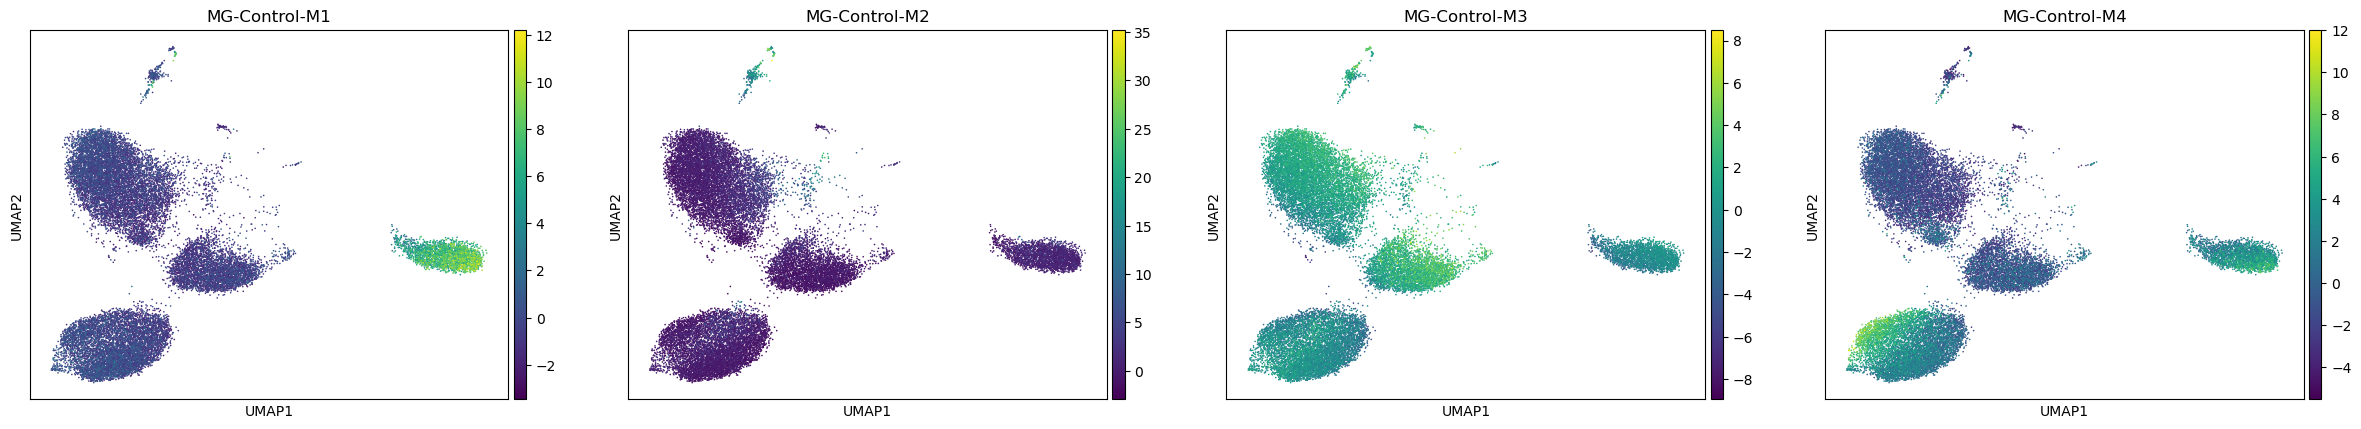

In [12]:
sc.pl.umap(adata_subsets[condition], color=modules)

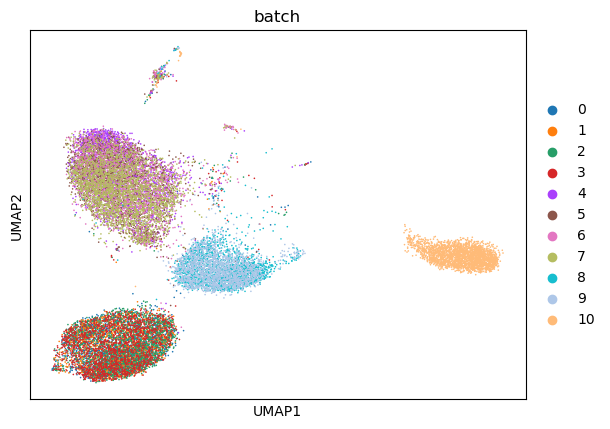

In [13]:
sc.pl.umap(adata_subsets[condition], color="batch")

## Saline

In [14]:
# Loading data for the condition
condition = "Saline"

In [15]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    f"/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_{condition}_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_SALINE-NoRP-M1,kME_grey,kME_SALINE-NoRP-M2,kME_SALINE-NoRP-M3
Apoe,Apoe,SALINE-NoRP-M1,blue,0.328732,0.441214,0.320913,0.270716
Ccl4,Ccl4,grey,grey,0.162866,0.414139,0.149515,0.129828
Ccl12,Ccl12,SALINE-NoRP-M1,blue,0.543086,0.105978,0.105050,0.050860
Ccl3,Ccl3,SALINE-NoRP-M1,blue,0.093986,0.320780,0.147746,0.129622
Lpl,Lpl,SALINE-NoRP-M1,blue,0.235353,0.472862,0.204790,0.199218


In [16]:
# Subsetting to only "control" cells
adata_subsets[condition] = mg_ad[mg_ad.obs['condition'] == condition].copy()

In [17]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("SALINE-NoRP", "MG-Saline")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Saline-M1', 'MG-Saline-M2', 'MG-Saline-M3']

In [18]:
# sc.pp.normalize_total(adata_subsets[condition], target_sum=1e4)
# sc.pp.log1p(adata_subsets[condition])
# sc.pp.scale(adata_subsets[condition], max_value=10)
# sc.tl.pca(adata_subsets[condition])
# sc.pp.neighbors(adata_subsets[condition])
# sc.tl.umap(adata_subsets[condition])

In [19]:
# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=adata_subsets[condition].obs_names)

# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = adata_subsets[condition].var_names.intersection(select_genes)
    adata_subset = adata_subsets[condition][:, common_genes].copy()
    
    # Perform PCA
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)
    sc.pp.scale(adata_subset, max_value=10)
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

    del adata_subset  # Free memory

# Run garbage collection to free up memory
gc.collect()

# Ensure the indices match
assert all(MEs_df.index == adata_subsets[condition].obs.index)

# Add the MEs_df to mg_control.obs
adata_subsets[condition].obs = adata_subsets[condition].obs.join(MEs_df)

# Verify the new columns
adata_subsets[condition].obs.head()

/home/bbbartelle/miniforge3/envs/CGNA/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/home/bbbartelle/miniforge3/envs/CGNA/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

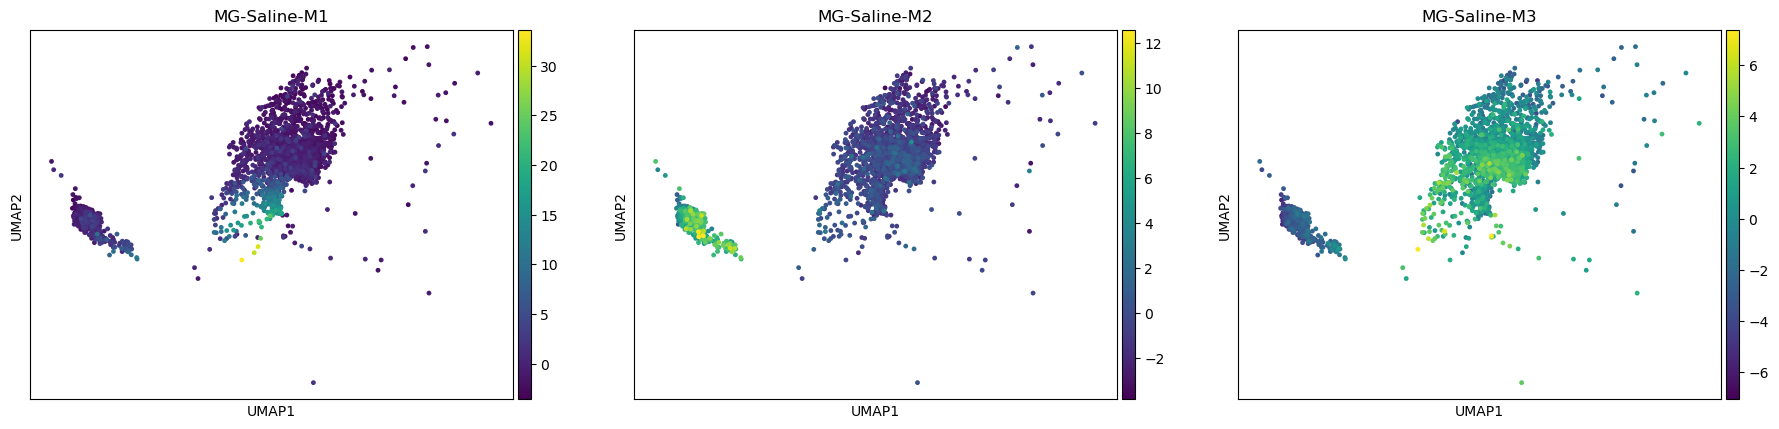

In [ ]:
sc.pl.umap(adata_subsets[condition], color=modules)

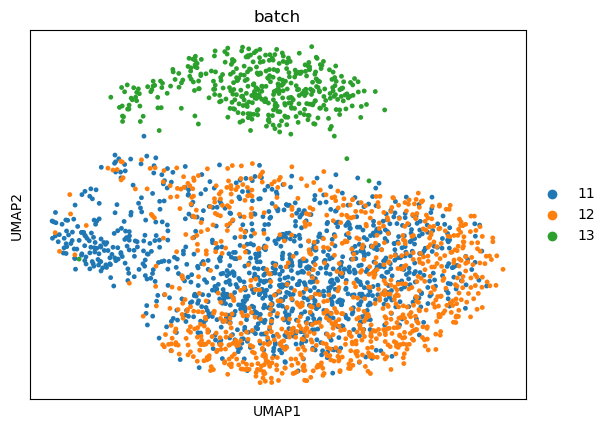

In [ ]:
sc.pl.umap(adata_subsets[condition], color="batch")

## LC

In [ ]:
# Loading data for the condition
condition = "LC"

In [ ]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    f"/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_{condition}_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_INJURY-NORP-M1,kME_INJURY-NORP-M2,kME_grey,kME_INJURY-NORP-M3
Ccl4,Ccl4,INJURY-NORP-M1,turquoise,0.449157,0.202290,0.093461,-0.192942
Cxcl10,Cxcl10,INJURY-NORP-M1,turquoise,0.448920,0.072827,0.053286,-0.153673
Ccl5,Ccl5,INJURY-NORP-M1,turquoise,0.306227,0.095109,0.015581,-0.194044
Ccl3,Ccl3,INJURY-NORP-M1,turquoise,0.413146,0.229298,0.095060,-0.208930
Ccl12,Ccl12,INJURY-NORP-M1,turquoise,0.496430,0.123100,0.075157,-0.224386


In [ ]:
# Subsetting to only "control" cells
adata_subsets[condition] = mg_ad[mg_ad.obs['condition'] == condition].copy()

In [ ]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("INJURY-NORP", "MG-LC")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-LC-M1', 'MG-LC-M2', 'MG-LC-M3']

In [ ]:
sc.pp.normalize_total(adata_subsets[condition], target_sum=1e4)
sc.pp.log1p(adata_subsets[condition])
sc.pp.scale(adata_subsets[condition], max_value=10)
sc.tl.pca(adata_subsets[condition])
sc.pp.neighbors(adata_subsets[condition])
sc.tl.umap(adata_subsets[condition])

In [ ]:
# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=adata_subsets[condition].obs_names)

# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = adata_subsets[condition].var_names.intersection(select_genes)
    adata_subset = adata_subsets[condition][:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

    del adata_subset  # Free memory

# Run garbage collection to free up memory
gc.collect()

# Ensure the indices match
assert all(MEs_df.index == adata_subsets[condition].obs.index)

# Add the MEs_df to mg_control.obs
adata_subsets[condition].obs = adata_subsets[condition].obs.join(MEs_df)

# Verify the new columns
adata_subsets[condition].obs.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,condition,MG-LC-M1,MG-LC-M2,MG-LC-M3
CCATTCGGTGAACCTT-1-14,14,2156,2156,6203.0,39.0,0.628728,LC,2.803358,1.578215,-0.322108
CGAATGTCAACAACCT-1-14,14,2177,2177,6690.0,3.0,0.044843,LC,4.586025,2.510895,-0.259157
CTAACTTGTAGCAAAT-1-14,14,1901,1901,5326.0,35.0,0.657154,LC,-1.044170,0.792709,2.214809
CTCCTAGTCTTTACGT-1-14,14,2154,2154,5475.0,36.0,0.657534,LC,3.590321,1.831689,2.962119
TCATTTGCAGCCACCA-1-14,14,1939,1939,5376.0,32.0,0.595238,LC,4.220525,1.901732,-0.917259


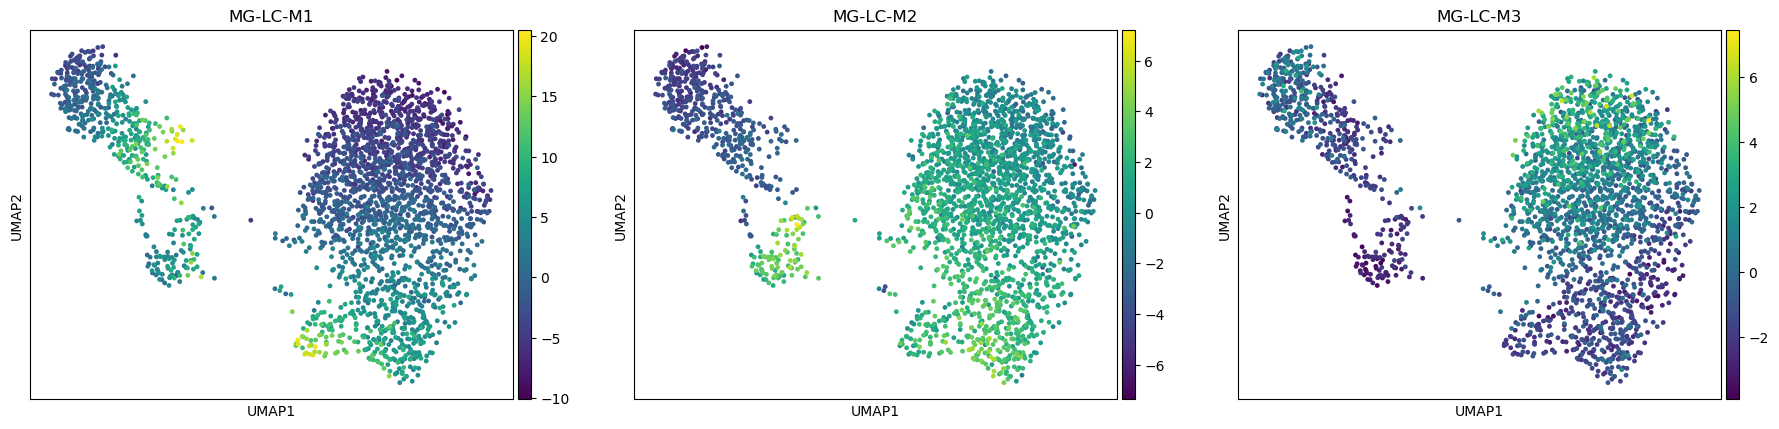

In [ ]:
sc.pl.umap(adata_subsets[condition], color=modules)

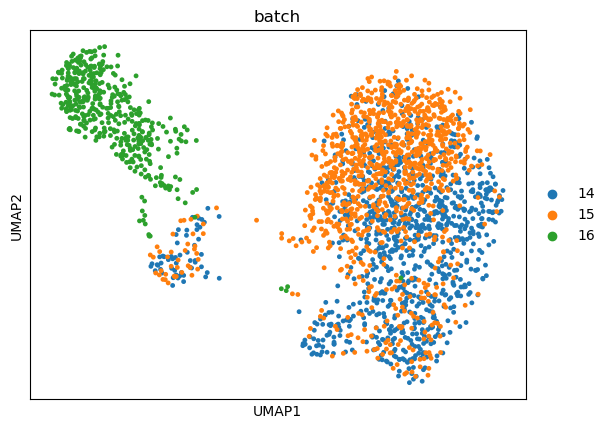

In [ ]:
sc.pl.umap(adata_subsets[condition], color="batch")